# 🚖 Ola Ride Insights Analysis
### Data Cleaning • EDA • Business Insights

## 📦 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 2. Loading Dataset

In [2]:
df = pd.read_excel("D:/STUDY MATERIAL/PROJECT/OLA PROJECT/Data/OLA_DataSet.xlsx")
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


## 🔍 3. Data Overview

In [3]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[us]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  str           
 3   Booking_Status              103024 non-null  str           
 4   Customer_ID                 103024 non-null  str           
 5   Vehicle_Type                103024 non-null  str           
 6   Pickup_Location             103024 non-null  str           
 7   Drop_Location               103024 non-null  str           
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   str           
 11  Canceled_Rides_by_Driver    18434 non-null   str  

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Booking_Value                     0
Payment_Method                39057
Ride_Distance                     0
Driver_Ratings                39057
Customer_Rating               39057
Vehicle Images                    0
dtype: int64

## 🧹 4. Data Cleaning

In [4]:
df.drop(columns=["Vehicle Images"], inplace=True, errors='ignore')

In [5]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Booking_Value'] = pd.to_numeric(df['Booking_Value'], errors='coerce')
df['Ride_Distance'] = pd.to_numeric(df['Ride_Distance'], errors='coerce')

In [6]:
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())
df['Driver_Ratings'] = df['Driver_Ratings'].fillna(df['Driver_Ratings'].median())

df['Incomplete_Rides_Reason'] = df['Incomplete_Rides_Reason'].fillna("Not Applicable")
df['Canceled_Rides_by_Customer'] = df['Canceled_Rides_by_Customer'].fillna("Not Cancelled")
df['Canceled_Rides_by_Driver'] = df['Canceled_Rides_by_Driver'].fillna("Not Cancelled")

## 🏗️ 5. Feature Engineering

In [7]:
df['Hour'] = df['Date'].dt.hour
df['Day'] = df['Date'].dt.day_name()
df['Revenue'] = df['Booking_Value']
df['Is_Successful'] = (df['Booking_Status'] == 'Success').astype(int)

## 💾 6. Saving Cleaned Data

In [8]:
df.to_csv("D:/STUDY MATERIAL/PROJECT/OLA PROJECT/Notebook/Ola_data_Clean.csv", index=False)

## 📊 7. Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv("D:\STUDY MATERIAL\PROJECT\OLA PROJECT\Notebook/Ola_data_Clean.csv")

## 🔹 Booking Status Distribution

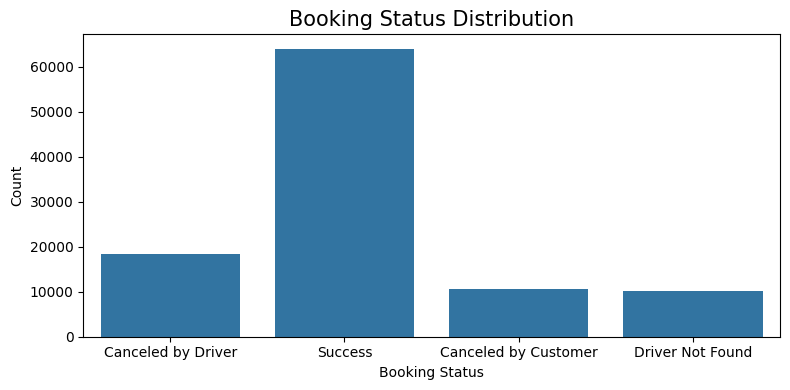

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(x='Booking_Status', data=df)
plt.title("Booking Status Distribution", fontsize=15, loc='center')
plt.xlabel("Booking Status", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🔹 Peak Ride Hours Analysis

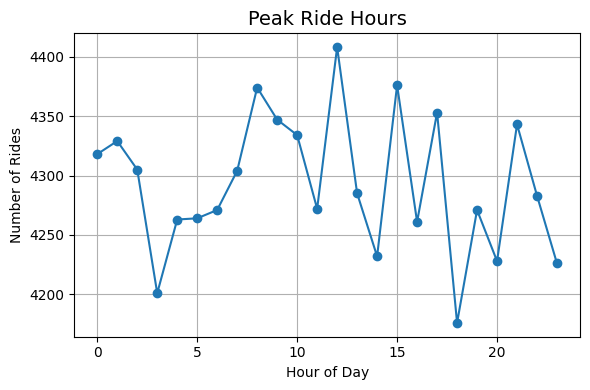

In [26]:
plt.figure(figsize=(6,4))
df.groupby('Hour').size().plot(marker='o')
plt.title("Peak Ride Hours", fontsize=14, loc='center')
plt.xlabel("Hour of Day", fontsize=10)
plt.ylabel("Number of Rides", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 Revenue by Payment Method

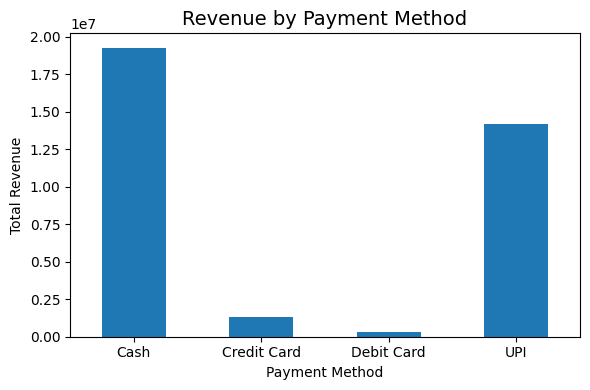

In [27]:
plt.figure(figsize=(6,4))
df.groupby('Payment_Method')['Revenue'].sum().plot(kind='bar')
plt.title("Revenue by Payment Method", fontsize=14, loc='center')
plt.xlabel("Payment Method", fontsize=10)
plt.ylabel("Total Revenue", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🔹 Customer Rating Distribution

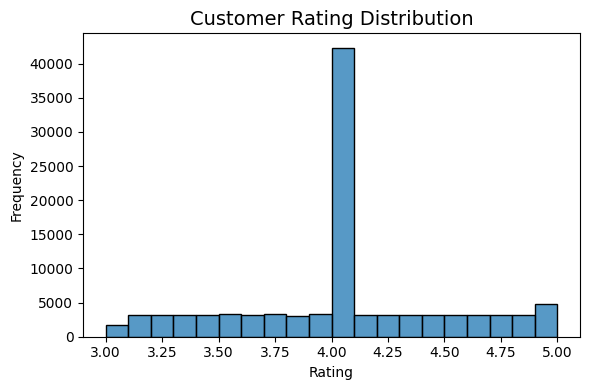

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df['Customer_Rating'], bins=20)
plt.title("Customer Rating Distribution", fontsize=14, loc='center')
plt.xlabel("Rating", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.tight_layout()
plt.show()

## **Insight:** Most bookings are successful, with a noticeable number of driver cancellations indicating operational inefficiencies.